# Setup

### imports and calcs setups

In [2]:
from ovito.io import import_file, export_file
from ovito.modifiers import CoordinationAnalysisModifier,TimeAveragingModifier
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown
from tqdm import tqdm
from ase.io import read
from scipy.fft import rfft, rfftfreq

In [3]:
!export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
!export DP_INFER_BATCH_SIZE=256

### export TF_GPU_ALLOCATOR=cuda_malloc_async

!export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK
!export DP_INTER_OP_PARALLELISM_THREADS=1

!export DP_INTRA_OP_PARALLELISM_THREADS=$SLURM_CPUS_PER_TASK

### calc setup

In [4]:
def calc_rdf(directory, model, recolour, num_bins=500, cutoff=8.0):
  # Load input trajectory
  pipeline = import_file(f"{directory}/trajectory_{model}_{recolour}.lammpstrj.gz")
  ##print(f"Number of MD frames: {pipeline.num_frames}")

  # Print available particle types
  ##for ptype in pipeline.compute().particles.particle_types.types:
      ##print(f"Type {ptype.id}: {ptype.name}")

  # Add RDF/coordination analysis modifier
  pipeline.modifiers.append(
      CoordinationAnalysisModifier(
          cutoff=cutoff,           # Maximum distance for RDF calculation
          number_of_bins=num_bins,    # Histogram bins
          partial=True           # Compute partial RDFs between atom types
      )
  )

  # Add time averaging modifier for the RDF table
  pipeline.modifiers.append(
      TimeAveragingModifier(operate_on="table:coordination-rdf")
  )

  # Add time averaging modifier for the system volume
  pipeline.modifiers.append(TimeAveragingModifier())

  # Compute averaged data
  data = pipeline.compute()

  # Compute averaged data
  data = pipeline.compute()

  # Get averaged volume
  avg_volume = data.cell.volume
  ##print(f"Average volume over trajectory: {avg_volume:.6f}")
  ##numpy.savetxt("volume_average.dat", avg_volume)

  # Access the averaged RDF table
  rdf_table = data.tables.get("coordination-rdf[average]")
  if rdf_table is None:
      raise RuntimeError("No RDF data found. Check if the modifiers are applied correctly.")

  # Save complete RDF table with OVITO exporter ---
  export_file(pipeline, f"rdf_{model}_{recolour}.dat", "txt/table", key="coordination-rdf[average]")
  print(f"Complete RDF data saved to: rdf_{model}_{recolour}.dat")

  #total_rdf = pipeline.compute().tables['coordination-rdf[average]'].xy()
  #print(total_rdf)


In [5]:
def calculate_vacf(directory, model, recolour, dt_fs=1.0, name="test"):
    """
    Рассчитывает VACF и его Фурье-образ с частотами в трех единицах.
    
    Параметры:
        trajectory_file: путь к XYZ-файлу
        dt_fs: шаг времени в фемтосекундах
    
    Возвращает:
        time, vacf - время (fs) и корреляционная функция
        freq_cm, freq_ps, freq_thz, vacf_fft - частоты и Фурье-образ
    """
    # Загрузка траектории
    traj = read(f"{directory}/trajectory_{model}_{recolour}_vel.lammpstrj.gz", index=':')
    n_frames = len(traj)
    
    # Получение скоростей
    velocities = np.array([atoms.get_velocities() for atoms in traj])


    # Расчет VACF
    velocities = velocities.reshape(n_frames, -1)
    norm = np.sum(velocities[0]**2)
    fft_vel = np.fft.fft(velocities, axis=0)
    fft_corr = fft_vel * np.conj(fft_vel)
    vacf = np.fft.ifft(fft_corr, axis=0).real / norm
    vacf = np.mean(vacf, axis=1)
    vacf = vacf / vacf[0]  # Нормировка VACF(0)=1

    # Временная ось [fs]
    time = np.arange(n_frames) * dt_fs
    
    '''
    # Фурье-преобразование
    dt_sec = dt_fs * 1e-15  # шаг времени в секундах
    vacf_fft = rfft(vacf)[1:]  # Убираем нулевую частоту
    freq_Hz = rfftfreq(n_frames, d=dt_sec)[1:]  # Частота в Герцах

    # Конвертация в разные единицы
    freq_cm = freq_Hz / 3e10          # см⁻¹ (спектроскопия)
    freq_ps = freq_Hz * 1e-12         # пикосекунды⁻¹
    freq_thz = freq_Hz * 1e-12        # терагерцы (1 THz = 10¹² Hz)
    '''
     
    np.savetxt(f"vacf_{model}_{recolour}.dat", vacf)

In [38]:
def calc_metrics(data_dict, model="mtp", recolours=["al170cu170ni170"], index=None, mode="rdf"):
    ans=dict()
    fc_ex1=[]
    fcor_ex1=[]
    fc_ex2=[]
    fcor_ex2=[]
    fc_int=[]
    fcor_int=[]
    for recolour in recolours:
        if mode=="vacf":
            centre=data_dict[f"{model}_centre_{recolour}"]
            corners=data_dict[f"{model}_corners_{recolour}"]
            full=data_dict[f"{model}_full_{recolour}"]
        elif mode=="rdf" and index is not None:
            centre=data_dict[f"{model}_centre_{recolour}"][:,index+1]
            corners=data_dict[f"{model}_corners_{recolour}"][:,index+1]
            full=data_dict[f"{model}_full_{recolour}"][:,index+1]
        
        if mode=="rdf":
            ex1_centre=centre[:180].max()
            ex1_centre_i=centre[:180].argmax()
            ex1_corners=corners[:180].max()
            ex1_corners_i=corners[:180].argmax()
            ex1_full=full[:180].max()
            ex1_full_i=full[:180].argmax()
        
            ex2_centre=centre[ex1_centre_i:].min()
            ex2_corners=corners[ex1_corners_i:].min()
            ex2_full=full[ex1_full_i:].min()
            
            #if recolour=="al490cu10ni10":
                #print(ex1_centre, ex1_corners, ex1_full, ex2_centre, ex2_corners, ex2_full)
        
        else:
            ex1_centre=centre.min()
            ex1_centre_i=centre.argmin()
            ex1_corners=corners.min()
            ex1_corners_i=corners.argmin()
            ex1_full=full.min()
            ex1_full_i=full.argmin()
        
            ex2_centre=centre[ex1_centre_i:].max()
            ex2_corners=corners[ex1_corners_i:].max()
            ex2_full=full[ex1_full_i:].max()
        
        fc_ex1.append(abs(ex1_full-ex1_centre)/abs(ex1_full))
        fcor_ex1.append(abs(ex1_full-ex1_corners)/abs(ex1_full))
        fc_ex2.append(abs(ex2_full-ex2_centre)/abs(ex2_full))
        fcor_ex2.append(abs(ex2_full-ex2_corners)/abs(ex2_full))
        fc_int.append(np.sqrt(((full-centre)**2).sum()/full.shape[0]))
        fcor_int.append(np.sqrt(((full-corners)**2).sum()/full.shape[0]))
        
            
    return (fc_ex1, fcor_ex1, fc_ex2, fcor_ex2, fc_int, fcor_int)

### plotting setup

In [7]:
def sci_not(recolour):
    c=recolour.find('c')
    n=recolour.find('n')
    return 'A'+recolour[1:c]+'C'+recolour[c+1:n]+'N'+recolour[n+1:]

In [8]:
def al_conc(recolours):
    ans=[]
    for recolour in recolours:
        ans.append(int(recolour.split('c')[0].split('l')[1]))
    return ans

In [9]:
map_index=["Al-Al","Al-Cu", "Al-Ni", "Cu-Cu", "Cu-Ni", "Ni-Ni"]

In [10]:
def plot_rdf_recolour(index=0, recolour="al170cu170ni170", font_s=12):
    plt.figure(figsize=(6, 6))
    
    for model in models:
        try:
            plt.plot(rdf_dict[f"{model}_al170cu170ni170"][:,0], rdf_dict[f"{model}_{recolour}"][:, index+1], label=" ".join(model.split("_")))
        except BaseException:
            pass
    plt.xlabel('Расстояние, Å', fontsize=font_s)
    plt.ylabel('Значение RDF', fontsize=font_s)

    name=f'RDF композиции {sci_not(recolour)}, пара {map_index[index]}'
    plt.title(name, fontsize=font_s)
    plt.grid(True)
    plt.legend(loc="upper right", fontsize=font_s)
    plt.show()

In [11]:
def plot_rdf_model(index=0, model="mtp_centre"):
    plt.figure(figsize=(6, 6))
    
    for recolour in recolours:
        try:
            plt.plot(rdf_dict[f"{model}_al170cu170ni170"][:,0], rdf_dict[f"{model}_{recolour}"][:, index+1], label=recolour)
        except BaseException:
            pass
    plt.xlabel('Distance r (Å)')
    plt.ylabel('g(r)')

    name=map_index[index]
    plt.title(f'{name} {model}')
    plt.grid(True)
    #plt.savefig(f'{name}.png', dpi=300)
    plt.legend()
    plt.show()

In [12]:
def plot_vacf_recolour(start=0, finish=5000+1, recolour="al170cu170ni170"):
    plt.figure(figsize=(6, 6))
    
    for model in models:
        try:
            plt.plot(np.arange(start,finish), vacf_dict[f"{model}_{recolour}"][start:finish], label=" ".join(model.split("_")))
        except BaseException as e:
            print(e)
    plt.xlabel('Время, фемтосекунды')
    plt.ylabel('Значение VACF')

    name=f"VACF композиции {sci_not(recolour)}"
    plt.title(f'{name}')
    plt.grid(True)
    #plt.savefig(f'{name}.png', dpi=300)
    plt.legend()
    plt.show()

In [13]:
def plot_vacf_model(start=0, finish=5000+1, model="deepmd_centre"):
    plt.figure(figsize=(6, 6))
    
    for recolour in recolours:
        try:
            plt.plot(np.arange(start,finish), vacf_dict[f"{model}_{recolour}"][start:finish], label=recolour)
        except BaseException:
            pass
    plt.xlabel('femtoseconds')
    plt.ylabel('VACF value')

    name=f"vacf {model}"
    plt.title(f'{name}')
    plt.grid(True)
    #plt.savefig(f'{name}.png', dpi=300)
    plt.legend()
    plt.show()

# Vacf

### vacf calcs

In [9]:
vacf_dict={}

In [24]:
models=["mtp_centre", "mtp_corners", "mtp_full"]
recolours=["al290cu110ni110","al370cu70ni70","al450cu30ni30","al470cu20ni20", "al490cu10ni10"]

In [25]:
for model in models:
    for recolour in recolours:
        calculate_vacf(f"../../rdf_calc/new/mtp/trajes_for_vacf_for_Fedor", model, recolour)

In [22]:
models=["deepmd_centre","deepmd_corners","deepmd_full"]
recolours=["al210cu150ni150","al290cu110ni110","al370cu70ni70","al410cu50ni50","al470cu20ni20", "al490cu10ni10"]

In [23]:
for model in models:
    for recolour in recolours:
        calculate_vacf(f"../../rdf_calc/new/deepmd/trajes_for_vacf", model, recolour)

### vacf plotting

In [14]:
models=["mtp_centre", "mtp_corners", "mtp_full", "deepmd_centre", "deepmd_corners", "deepmd_full"]
recolours=["al170cu170ni170", "al180cu160ni170","al200cu150ni160","al210cu150ni150","al250cu130ni130", "al290cu110ni110",
           "al330cu90ni90", "al370cu70ni70","al410cu50ni50","al450cu30ni30","al470cu20ni20", "al490cu10ni10", "al510cu0ni0"]

In [15]:
vacf_dict=dict()
for model in models:
    for recolour in recolours:
        try:
            vacf_dict[f"{model}_{recolour}"]=np.loadtxt(f"vacf_{model}_{recolour}.dat", dtype=float)
        except BaseException:
            pass

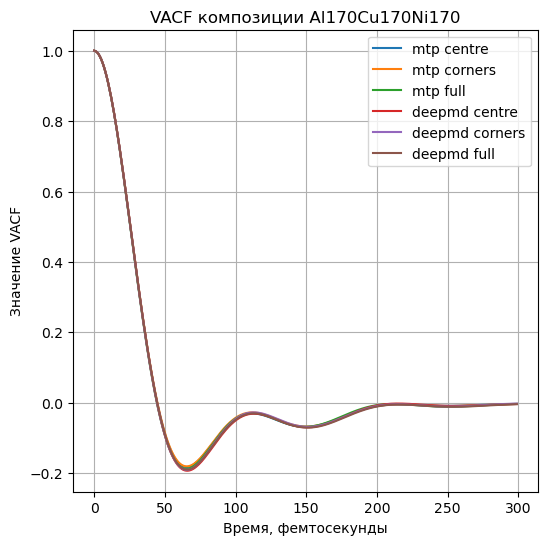

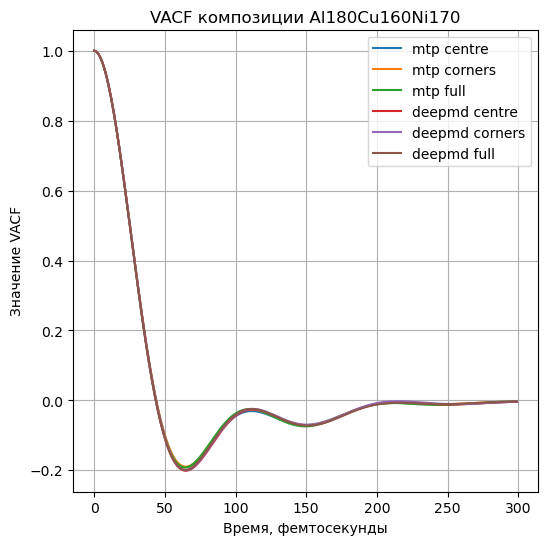

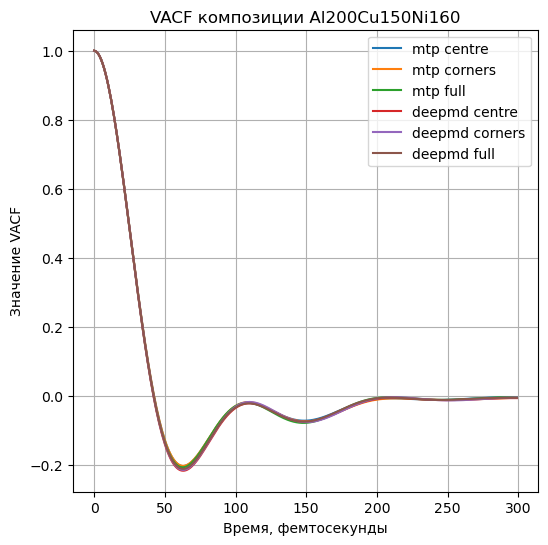

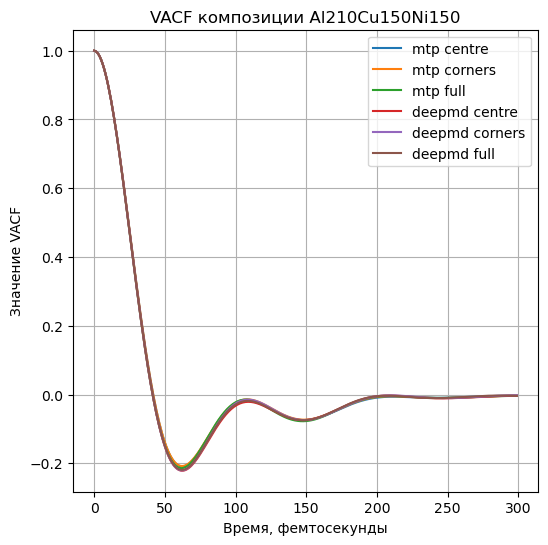

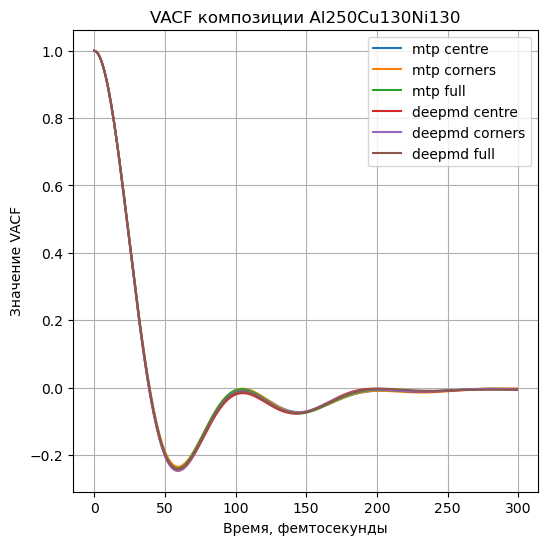

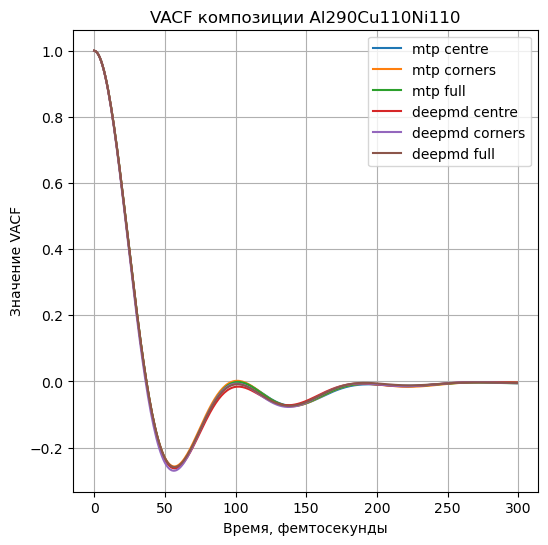

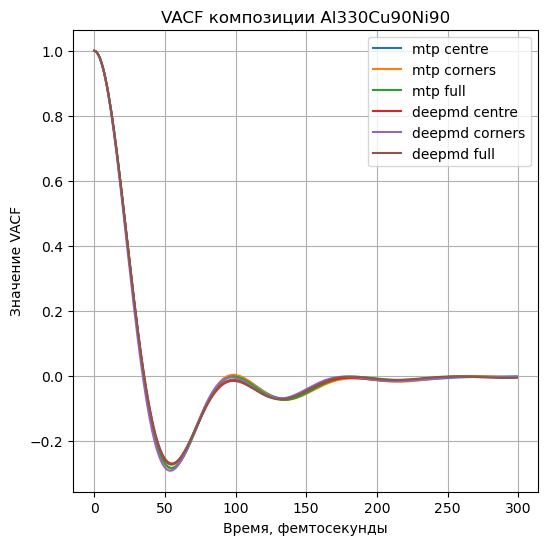

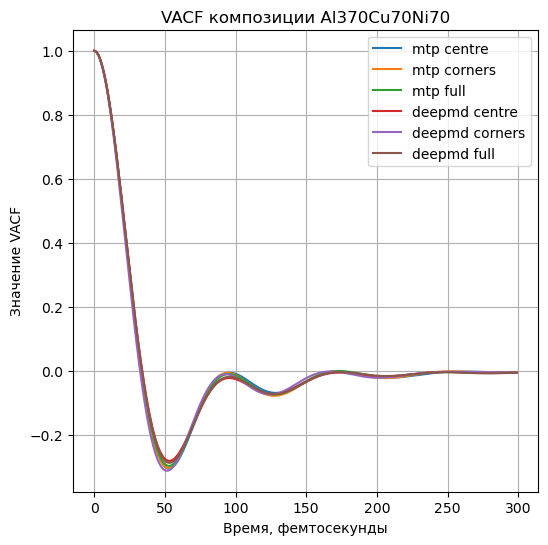

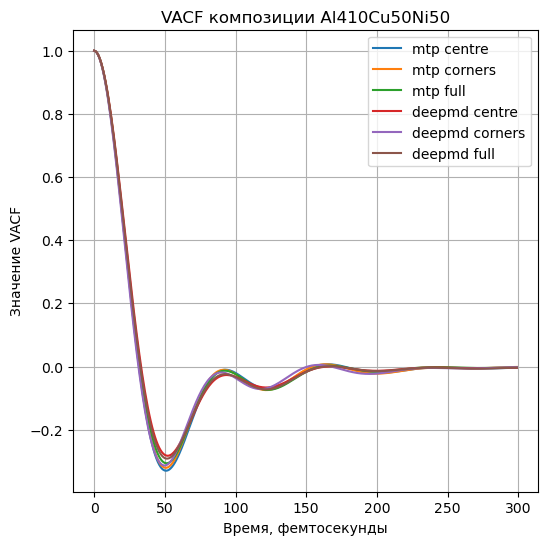

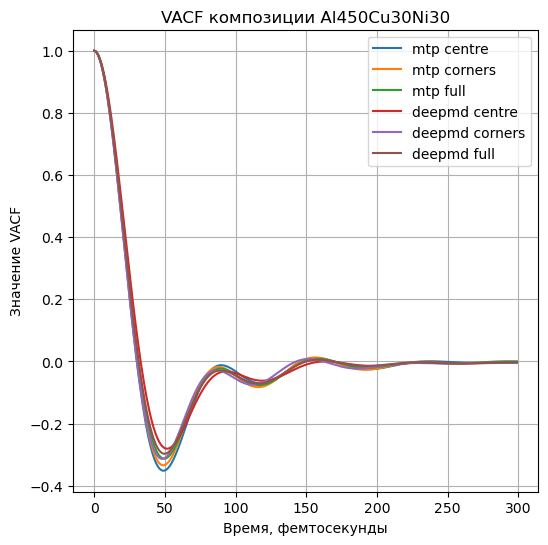

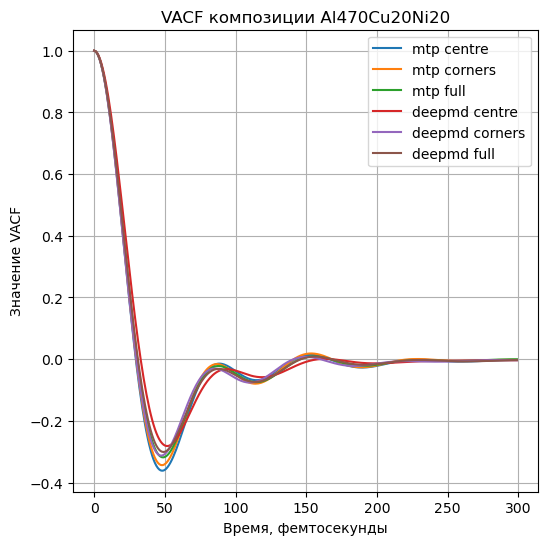

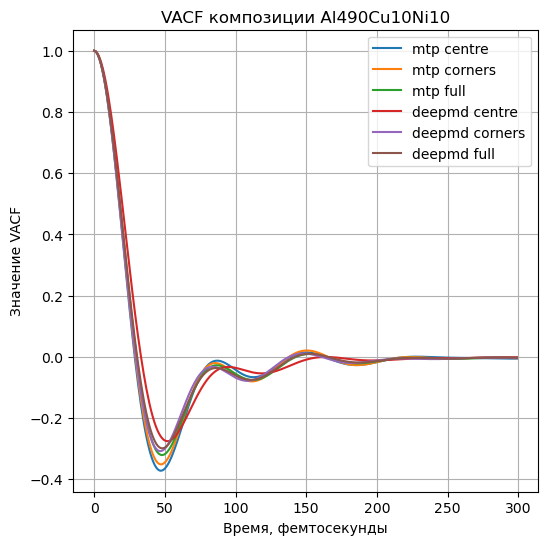

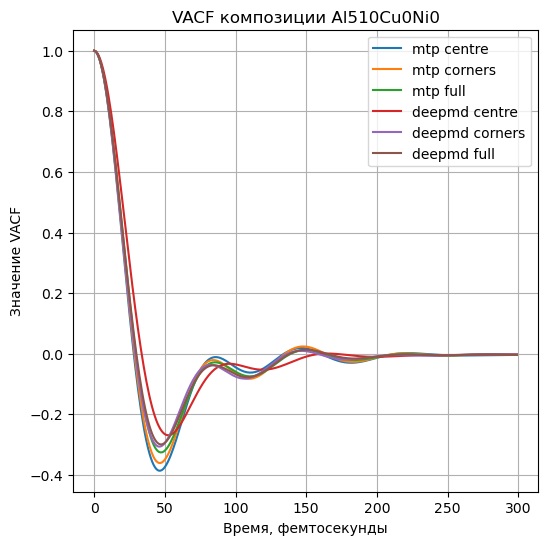

In [16]:
for recolour in recolours:
    plot_vacf_recolour(finish=300, recolour=recolour)

In [ ]:
for model in models:
    plot_vacf_model(finish=300, model=model)

In [78]:
vacf_dict=dict()
for model in models:
    for recolour in recolours:
        try:
            vacf_dict[f"{model}_{recolour}"]=np.loadtxt(f"vacf_{model}_{recolour}.dat", dtype=float)
        except BaseException:
            pass

In [79]:
ans_mtp_vacf=calc_metrics(vacf_dict, model="mtp", recolours=recolours, mode="vacf")

In [80]:
ans_deepmd_vacf=calc_metrics(vacf_dict, model="deepmd", recolours=recolours, mode="vacf")

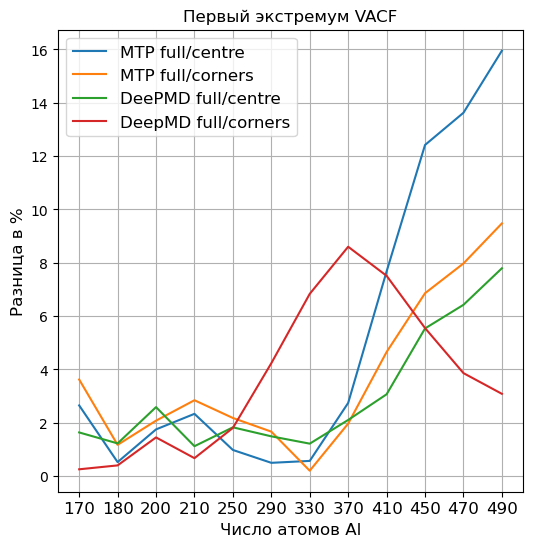

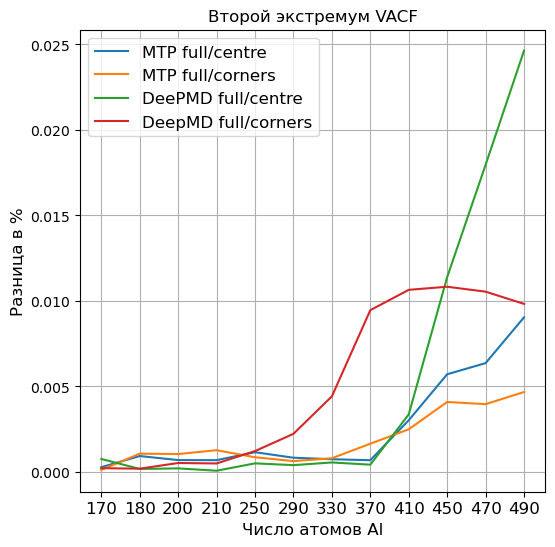

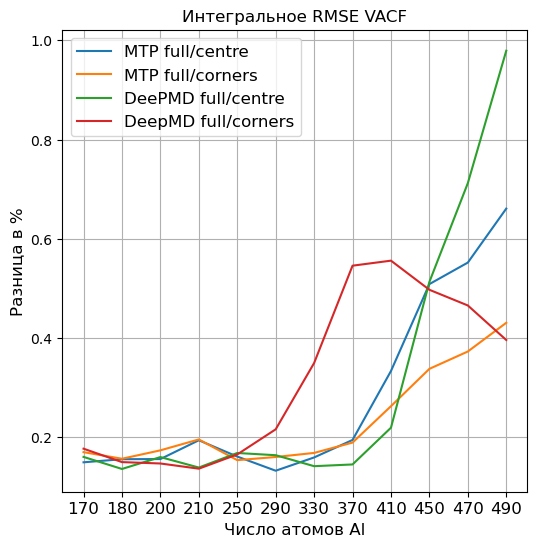

In [81]:
metrics=["full/centre_ex1", "full/corners_ex1", "full/centre_ex2", "full/corners_ex2","full/centre_integral","full/corners_integral"]
ans_mtp_vacf_np=np.array(ans_mtp_vacf)
ans_deepmd_vacf_np=np.array(ans_deepmd_vacf)

for i in range(0, len(metrics), 2):
    plt.figure(figsize=(6, 6))
    if i==0:
        plt.title("Первый экстремум VACF", fontsize=12)
    elif i==2:
        plt.title("Второй экстремум VACF", fontsize=12)
    else:
        plt.title("Интегральное RMSE VACF", fontsize=12)
    plt.plot(ans_mtp_vacf_np[i]*100, label="MTP full/centre")
    plt.plot(ans_mtp_vacf_np[i+1]*100, label="MTP full/corners")
    plt.plot(ans_deepmd_vacf_np[i]*100, label="DeePMD full/centre")
    plt.plot(ans_deepmd_vacf_np[i+1]*100, label="DeepMD full/corners")
    plt.xticks(np.arange(len(recolours)), al_conc(recolours), size=12)
    plt.xlabel("Число атомов Al", fontsize=12)
    plt.ylabel("Разница в %", fontsize=12)
    plt.grid()
    plt.legend(fontsize=12)
    plt.show()

# RDF

### rdf calc

In [14]:
models=["deepmd_centre", "deepmd_corners", "deepmd_full"]
# recolours=["al290cu110ni110","al370cu70ni70","al450cu30ni30","al470cu20ni20","al490cu10ni10",]
recolours=["al210cu150ni150","al290cu110ni110","al370cu70ni70","al410cu50ni50","al450cu30ni30","al470cu20ni20", "al490cu10ni10"]


for model in models:
    for recolour in recolours:
        calc_rdf("../../rdf_calc/new/deepmd/trajes_for_rdf", model, recolour)

Complete RDF data saved to: rdf_deepmd_centre_al210cu150ni150.dat
Complete RDF data saved to: rdf_deepmd_centre_al290cu110ni110.dat
Complete RDF data saved to: rdf_deepmd_centre_al370cu70ni70.dat
Complete RDF data saved to: rdf_deepmd_centre_al410cu50ni50.dat
Complete RDF data saved to: rdf_deepmd_centre_al450cu30ni30.dat
Complete RDF data saved to: rdf_deepmd_centre_al470cu20ni20.dat
Complete RDF data saved to: rdf_deepmd_centre_al490cu10ni10.dat
Complete RDF data saved to: rdf_deepmd_corners_al210cu150ni150.dat
Complete RDF data saved to: rdf_deepmd_corners_al290cu110ni110.dat
Complete RDF data saved to: rdf_deepmd_corners_al370cu70ni70.dat
Complete RDF data saved to: rdf_deepmd_corners_al410cu50ni50.dat
Complete RDF data saved to: rdf_deepmd_corners_al450cu30ni30.dat
Complete RDF data saved to: rdf_deepmd_corners_al470cu20ni20.dat
Complete RDF data saved to: rdf_deepmd_corners_al490cu10ni10.dat
Complete RDF data saved to: rdf_deepmd_full_al210cu150ni150.dat
Complete RDF data saved t

### metrics calc

In [41]:
#models=["mtp_centre", "mtp_corners", "mtp_full", "deepmd_centre", "deepmd_corners", "deepmd_full"]
models=["mtp_centre", "mtp_corners", "mtp_full", "deepmd_centre", "deepmd_corners", "deepmd_full"]
recolours=["al170cu170ni170", "al180cu160ni170","al200cu150ni160","al210cu150ni150","al250cu130ni130", "al290cu110ni110",
           "al330cu90ni90", "al370cu70ni70","al410cu50ni50","al450cu30ni30","al470cu20ni20", "al490cu10ni10"]

rdf_dict=dict()
for model in models:
    for recolour in recolours:
        try:
            rdf_dict[f"{model}_{recolour}"]=np.loadtxt(f"rdf_{model}_{recolour}.dat", dtype=float)
        except BaseException:
            pass

In [45]:
ans_mtp=calc_metrics(
    rdf_dict, model="mtp", 
    recolours=recolours, index=0)

In [46]:
ans_deepmd=calc_metrics(rdf_dict, model="deepmd", recolours=recolours, index=0)

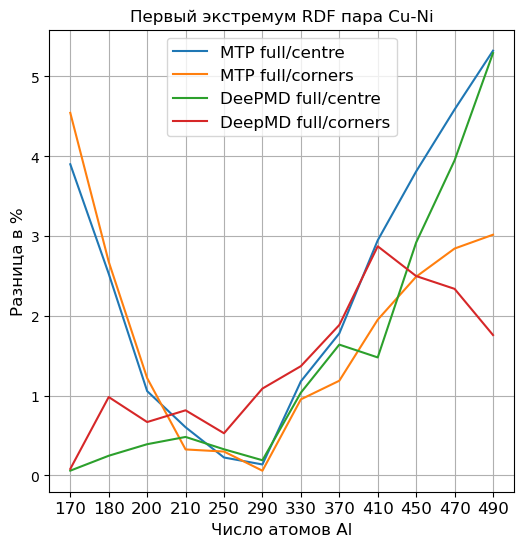

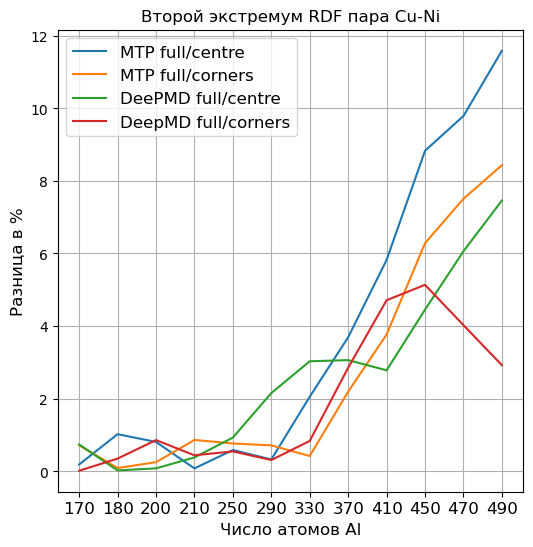

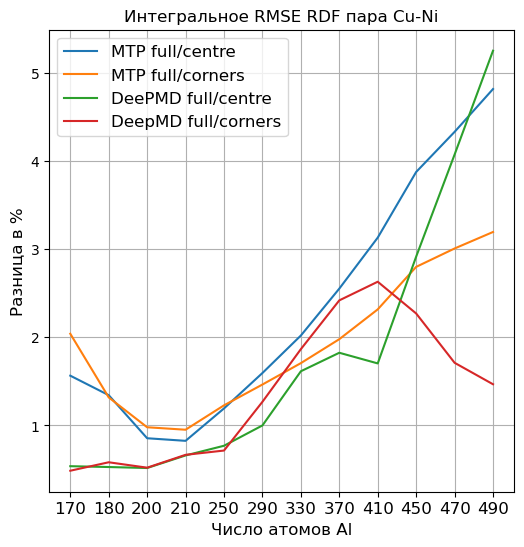

In [47]:
metrics=["full/centre_ex1", "full/corners_ex1", "full/centre_ex2", "full/corners_ex2","full/centre_integral","full/corners_integral"]
recolours=["al170cu170ni170", "al180cu160ni170","al200cu150ni160","al210cu150ni150","al250cu130ni130","al290cu110ni110",
           "al330cu90ni90","al370cu70ni70","al410cu50ni50","al450cu30ni30","al470cu20ni20","al490cu10ni10",]
ans_mtp_np=np.array(ans_mtp)
ans_deepmd_np=np.array(ans_deepmd)

for i in range(0, len(metrics), 2):
    plt.figure(figsize=(6, 6))
    if i==0:
        plt.title("Первый экстремум RDF пара Cu-Ni", fontsize=12)
    elif i==2:
        plt.title("Второй экстремум RDF пара Cu-Ni", fontsize=12)
    else:
        plt.title("Интегральное RMSE RDF пара Cu-Ni", fontsize=12)       
    plt.plot(ans_mtp_np[i]*100, label="MTP full/centre")
    plt.plot(ans_mtp_np[i+1]*100, label="MTP full/corners")
    plt.plot(ans_deepmd_np[i]*100, label="DeePMD full/centre")
    plt.plot(ans_deepmd_np[i+1]*100, label="DeepMD full/corners")
    plt.xticks(np.arange(len(recolours)), al_conc(recolours), size=12)
    plt.xlabel("Число атомов Al", fontsize=12)
    plt.ylabel("Разница в %", fontsize=12)
    plt.grid()
    plt.legend(fontsize=12)
    plt.show()

### rdf plotting

In [82]:
models=["mtp_centre", "mtp_corners", "mtp_full", "deepmd_centre", "deepmd_corners", "deepmd_full"]
recolours=["al170cu170ni170", "al180cu160ni170","al200cu150ni160","al210cu150ni150","al250cu130ni130","al290cu110ni110",
           "al330cu90ni90","al370cu70ni70","al410cu50ni50","al450cu30ni30","al470cu20ni20","al490cu10ni10",]

In [83]:
rdf_dict=dict()
for model in models:
    for recolour in recolours:
        try:
            rdf_dict[f"{model}_{recolour}"]=np.loadtxt(f"rdf_{model}_{recolour}.dat", dtype=float)
        except BaseException:
            pass

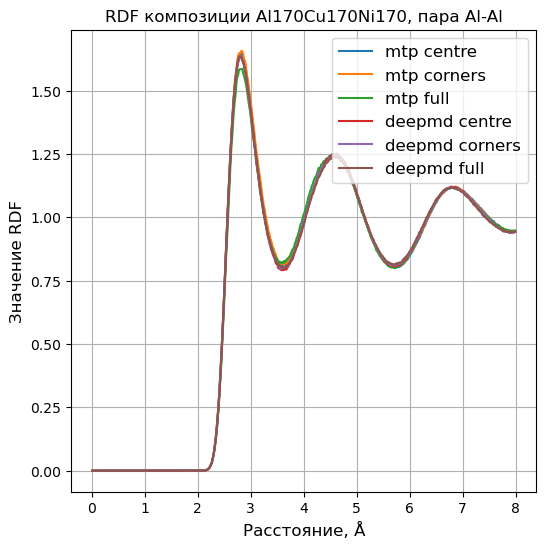

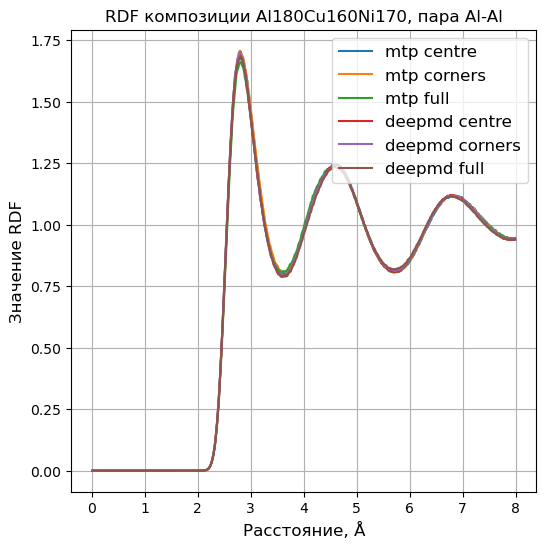

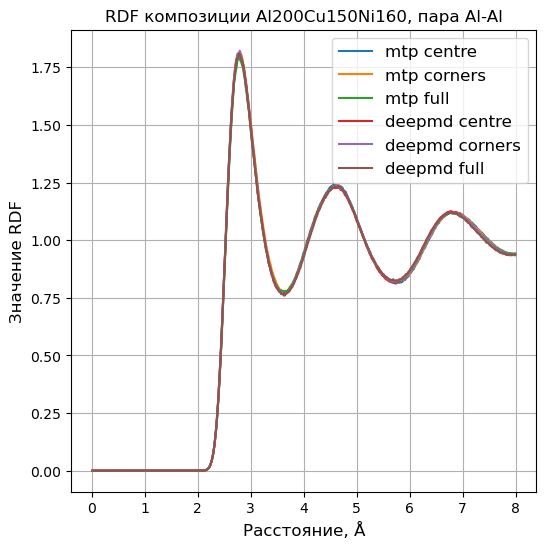

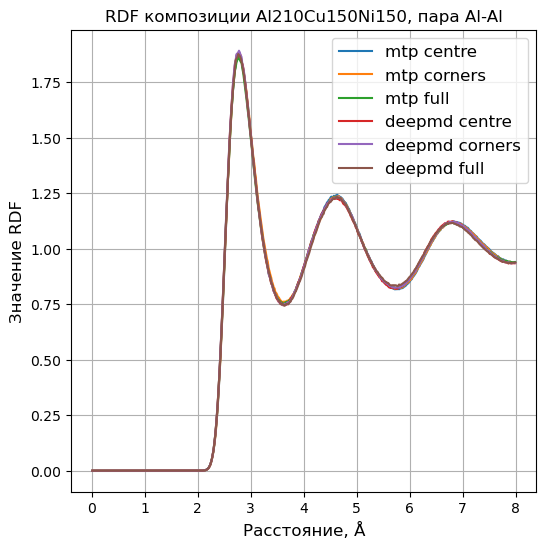

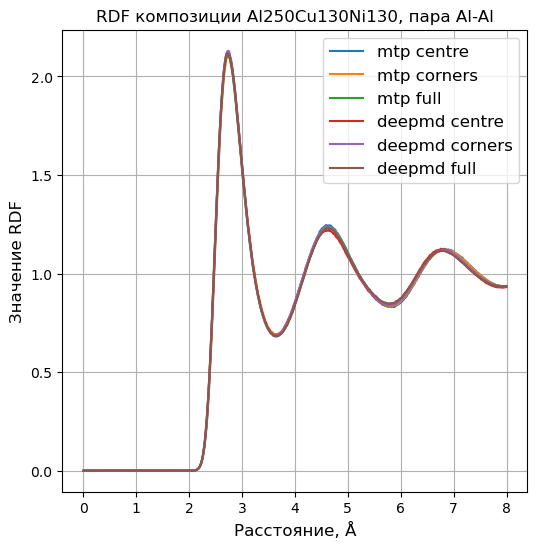

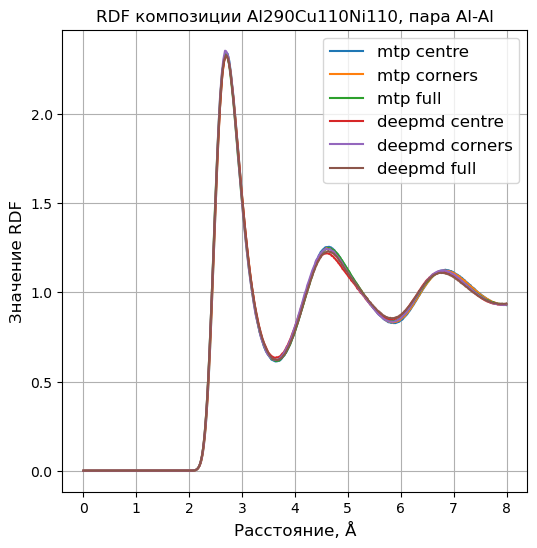

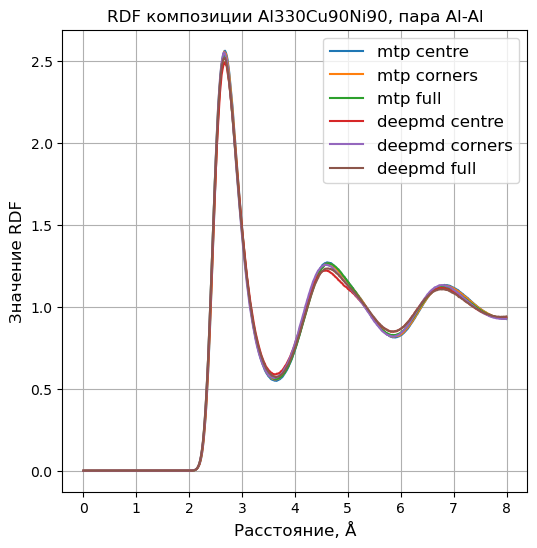

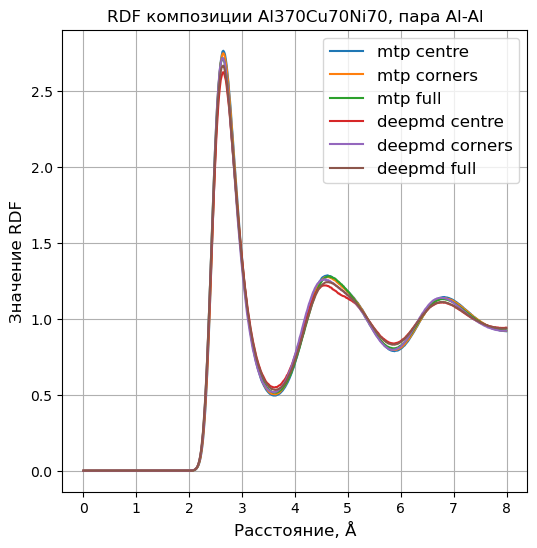

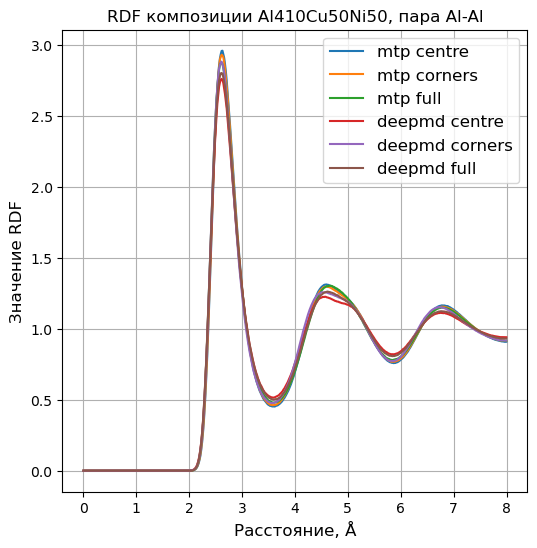

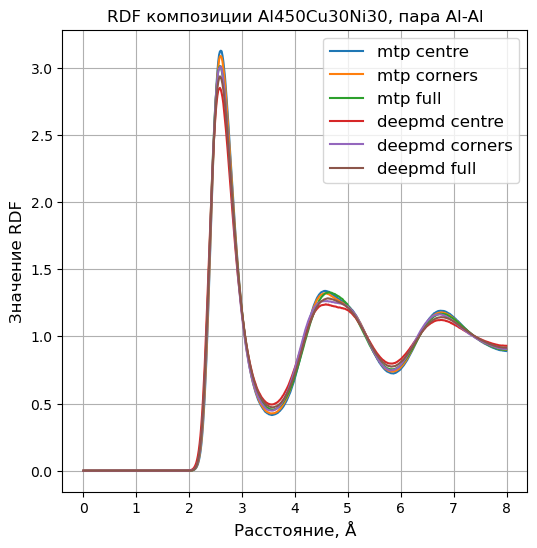

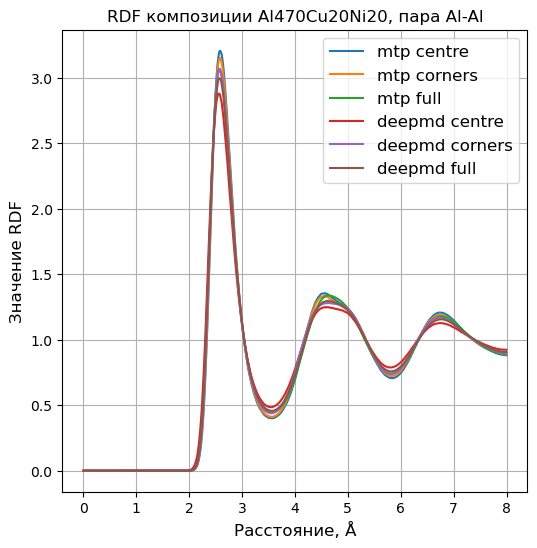

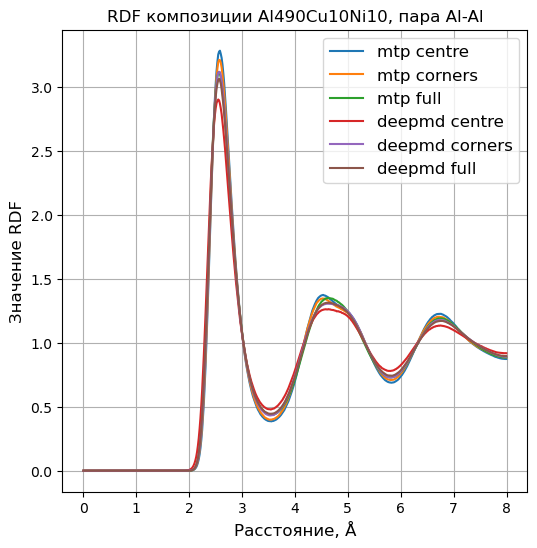

In [48]:
for recolour in recolours:
    plot_rdf_recolour(index=0,recolour=recolour)

## Density

In [65]:
models=["mtp_centre", "mtp_corners", "mtp_full", "deepmd_centre", "deepmd_corners", "deepmd_full"]
recolours=["al170cu170ni170", "al180cu160ni170","al200cu150ni160","al210cu150ni150","al250cu130ni130","al290cu110ni110",
           "al330cu90ni90","al370cu70ni70","al410cu50ni50","al450cu30ni30","al470cu20ni20","al490cu10ni10","al510cu0ni0"]

densities=np.array([
[5.94, 5.84, 5.61, 5.48, 5.02, 4.51, 4.04, 3.58, 3.16, 2.77, 2.58, 2.40, 2.24],
[6.09, 5.98, 5.74, 5.59, 5.11, 4.61, 4.11, 3.62, 3.14, 2.68, 2.45, 2.18, 0],
[6.08, 5.96, 5.70, 5.56, 5.04, 4.52, 4.03, 3.54, 3.05, 0, 0, 0, 0],

[6.11, 5.98, 5.74, 5.61, 5.12, 4.65, 4.21, 3.77, 3.22, 2.85, 2.63, 2.41, 2.21],
[6.10, 5.99, 5.74, 5.62, 5.17, 4.69, 4.24, 3.81, 3.35, 2.86, 2.65, 2.43, 2.23],
[6.08, 5.96, 5.71, 5.58, 5.05, 4.52, 4.03, 3.58, 3.16, 2.78, 2.59, 2.41, 2.25],
])

densities2=np.array([
    [5.94, 5.84, 5.61, 5.48, 5.02, 4.51, 4.04, 3.58, 3.16, 2.77, 2.58, 2.40, 2.24],
    [6.09, 5.98, 5.74, 5.59, 5.11, 4.61, 4.11, 3.62, 3.14, 2.68, 2.45, 2.18, 2.10],
    [6.08, 5.96, 5.70, 5.56, 5.04, 4.52, 4.03, 3.54, 3.05, 2.61, 2.52, 2.38, 2.20],

    [6.11, 5.98, 5.74, 5.61, 5.12, 4.65, 4.21, 3.77, 3.22, 2.85, 2.63, 2.41, 2.21],
    [6.10, 5.99, 5.74, 5.62, 5.17, 4.69, 4.24, 3.81, 3.35, 2.86, 2.65, 2.43, 2.23],
    [6.08, 5.96, 5.71, 5.58, 5.05, 4.52, 4.03, 3.58, 3.16, 2.78, 2.59, 2.41, 2.25],
])

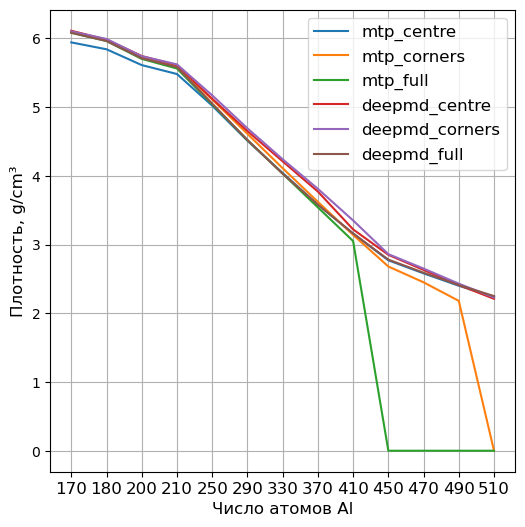

In [66]:
plt.figure(figsize=(6, 6))
for i in range(len(models)):
    plt.plot(densities[i], label=models[i])

plt.grid(True)
plt.xticks(np.arange(len(recolours)), recolours, size=12)
plt.xticks(np.arange(len(recolours)), al_conc(recolours), size=12)
plt.ylabel("Плотность, g/cm³", fontsize=12)
plt.xlabel("Число атомов Al", fontsize=12)
plt.legend(fontsize=12)
plt.show()